In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class CricketerStats(TypedDict):
    runs: int
    balls:int
    fours:int
    sixes:int
    
    sr: float
    bpb: float
    boundary_percentage: float

In [29]:
graph = StateGraph(CricketerStats)

In [30]:
def calc_sr(state: CricketerStats) :
    state["sr"] = (state["runs"] / state["balls"]) * 100
    return {'sr': state["sr"]}

def calc_bpb(state: CricketerStats) :
    state["bpb"] = state["balls"] / (state["fours"] + state["sixes"])
    return {'bpb': state["bpb"]}

def calc_boundary_percentage(state: CricketerStats) :
    state["boundary_percentage"] = ((state["fours"] * 4) + (state["sixes"] * 6)) / state["runs"]
    return {'boundary_percentage': state["boundary_percentage"]}

def summary(state: CricketerStats) -> CricketerStats:
    print("Summary of Cricketer Stats:")
    print(f"Runs: {state['runs']}")
    print(f"Balls: {state['balls']}")
    print(f"Fours: {state['fours']}")
    print(f"Sixes: {state['sixes']}")
    print(f"Strike Rate: {state['sr']:.2f}")
    print(f"Balls Per Boundary: {state['bpb']:.2f}")
    print(f"Boundary Percentage: {state['boundary_percentage']:.2%}")
    return state

In [31]:
graph.add_node("calc_sr", calc_sr)
graph.add_node("calc_bpb", calc_bpb)
graph.add_node("calc_boundary_percentage", calc_boundary_percentage)
graph.add_node("summary", summary)

In [32]:
graph.add_edge(START, "calc_sr") #Super-step 1: Calculate Strike Rate
graph.add_edge(START, "calc_bpb") #Super-step 1: Calculate Balls Per Boundary
graph.add_edge(START, "calc_boundary_percentage") #Super-step 1: Calculate Boundary Percentage
graph.add_edge("calc_sr", "summary") #Super-step 2: Summary after Strike Rate
graph.add_edge("calc_bpb", "summary") #Super-step 2: Summary after Balls Per Boundary
graph.add_edge("calc_boundary_percentage", "summary") #Super-step 2: Summary after Boundary Percentage
graph.add_edge("summary", END)
workflow = graph.compile()

In [33]:
input_state = {
    "runs" : 100,
    "balls": 60,
    "fours": 10,
    "sixes": 5
}
input_state = CricketerStats(**input_state)

In [34]:
output_state = workflow.invoke(input_state) #type: ignore

Summary of Cricketer Stats:
Runs: 100
Balls: 60
Fours: 10
Sixes: 5
Strike Rate: 166.67
Balls Per Boundary: 4.00
Boundary Percentage: 70.00%


In [35]:
print("Final Output State:")
print(output_state)

Final Output State:
{'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5, 'sr': 166.66666666666669, 'bpb': 4.0, 'boundary_percentage': 0.7}


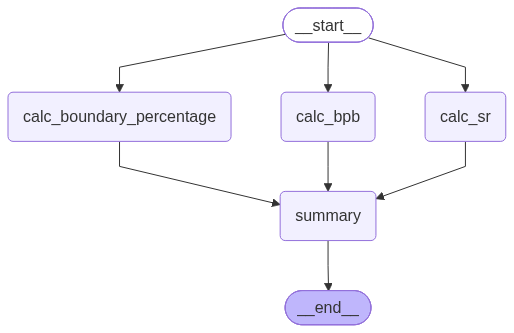

In [36]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())